In [ ]:
# importing libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline

from scipy.stats import skew, kurtosis

In [158]:
students = pd.read_csv("C:/Users/Home/Desktop/FYP/EduMate-AI/data/student.csv")

In [159]:
students

,student_id,name,email,course,learning_style,communication,personality,gpa
0,S0001,Hassan Qureshi,hassan.qureshi68@student.edu.pk,Data Science,Kinesthetic,Average,Ambivert,2.84
1,S0002,Usman Rana,usman.rana681@student.edu.pk,Artificial Intelligence,Auditory,Strong,Introvert,2.17
2,S0003,Ahmad Iftikhar,ahmad.iftikhar869@student.edu.pk,Cyber Security,Reading/Writing,Average,Introvert,2.59
3,S0004,Hassan Iftikhar,hassan.iftikhar936@student.edu.pk,Information Technology,Reading/Writing,Weak,Extrovert,3.44
4,S0005,Sana Butt,sana.butt327@student.edu.pk,Software Engineering,Reading/Writing,Strong,Introvert,2.85
...,...,...,...,...,...,...,...,...
495,S0496,Fatima Ashraf,fatima.ashraf990@student.edu.pk,Data Science,Auditory,Strong,Introvert,3.99
496,S0497,Bilal Qureshi,bilal.qureshi373@student.edu.pk,Software Engineering,Kinesthetic,Strong,Ambivert,3.07
497,S0498,Jawad Ashraf,jawad.ashraf313@student.edu.pk,Information Technology,Visual,Weak,Extrovert,2.16
498,S0499,Fatima Qureshi,fatima.qureshi681@student.edu.pk,Cyber Security,Visual,Strong,Extrovert,2.99


In [160]:
students.columns

Index(['student_id', 'name', 'email', 'course', 'learning_style',
       'communication', 'personality', 'gpa'],
      dtype='object')

In [161]:
students.shape

(500, 8)

In [162]:
students.sample(10)

,student_id,name,email,course,learning_style,communication,personality,gpa
260,S0261,Ahmad Siddiqui,ahmad.siddiqui603@student.edu.pk,Deep Learning,Kinesthetic,Average,Ambivert,2.47
40,S0041,Hassan Siddiqui,hassan.siddiqui73@student.edu.pk,Computer Networks,Kinesthetic,Average,Ambivert,2.69
118,S0119,Sana Chaudhry,sana.chaudhry197@student.edu.pk,Artificial Intelligence,Reading/Writing,Weak,Extrovert,2.03
214,S0215,Fatima Chaudhry,fatima.chaudhry380@student.edu.pk,Artificial Intelligence,Reading/Writing,Weak,Extrovert,2.48
80,S0081,Muneeb Sheikh,muneeb.sheikh193@student.edu.pk,Cyber Security,Kinesthetic,Weak,Introvert,2.02
397,S0398,Zara Ashraf,zara.ashraf30@student.edu.pk,Cyber Security,Auditory,Weak,Introvert,3.76
252,S0253,Bilal Siddiqui,bilal.siddiqui845@student.edu.pk,Artificial Intelligence,Kinesthetic,Strong,Extrovert,3.37
229,S0230,Muneeb Qureshi,muneeb.qureshi953@student.edu.pk,Cloud Computing,Reading/Writing,Weak,Ambivert,2.09
344,S0345,Hiba Iftikhar,hiba.iftikhar328@student.edu.pk,Information Technology,Reading/Writing,Average,Extrovert,2.10
407,S0408,Hassan Butt,hassan.butt588@student.edu.pk,Data Science,Auditory,Average,Extrovert,2.60


In [163]:
students.nunique()

student_id        500
name              137
email             499
course              9
learning_style      4
communication       3
personality         3
gpa               186
dtype: int64

In [164]:
students.drop(columns = ['email'], inplace = True)

In [165]:
students.shape

(500, 7)

In [166]:
students.info(verbose = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   student_id      500 non-null    object 
 1   name            500 non-null    object 
 2   course          500 non-null    object 
 3   learning_style  500 non-null    object 
 4   communication   500 non-null    object 
 5   personality     500 non-null    object 
 6   gpa             500 non-null    float64
dtypes: float64(1), object(6)
memory usage: 27.5+ KB


In [167]:
students.dtypes

student_id         object
name               object
course             object
learning_style     object
communication      object
personality        object
gpa               float64
dtype: object

In [168]:
print(f"<========== HANDLING MISSING VALUES ==========>")
print("")
print(f"Missing Values:")
print(f"{students.isnull().sum()}")

<========== HANDLING MISSING VALUES ==========>

Missing Values:
student_id        0
name              0
course            0
learning_style    0
communication     0
personality       0
gpa               0
dtype: int64


In [169]:
print(f"<========== DUPLICATE ROWS ==========>")
print("")
print(f"Duplicate Rows are: {students.duplicated().sum()}")

<========== DUPLICATE ROWS ==========>

Duplicate Rows are: 0


In [170]:
students.corr(method='pearson', numeric_only=True)

,gpa
gpa,1.0


In [171]:
students.head()

,student_id,name,course,learning_style,communication,personality,gpa
0,S0001,Hassan Qureshi,Data Science,Kinesthetic,Average,Ambivert,2.84
1,S0002,Usman Rana,Artificial Intelligence,Auditory,Strong,Introvert,2.17
2,S0003,Ahmad Iftikhar,Cyber Security,Reading/Writing,Average,Introvert,2.59
3,S0004,Hassan Iftikhar,Information Technology,Reading/Writing,Weak,Extrovert,3.44
4,S0005,Sana Butt,Software Engineering,Reading/Writing,Strong,Introvert,2.85


In [172]:
students.head()

,student_id,name,course,learning_style,communication,personality,gpa
0,S0001,Hassan Qureshi,Data Science,Kinesthetic,Average,Ambivert,2.84
1,S0002,Usman Rana,Artificial Intelligence,Auditory,Strong,Introvert,2.17
2,S0003,Ahmad Iftikhar,Cyber Security,Reading/Writing,Average,Introvert,2.59
3,S0004,Hassan Iftikhar,Information Technology,Reading/Writing,Weak,Extrovert,3.44
4,S0005,Sana Butt,Software Engineering,Reading/Writing,Strong,Introvert,2.85


In [173]:
# Clean and standardize text columns
text_columns = ['name', 'course', 'learning_style', 'communication', 'personality']
for col in text_columns:
    if col in students.columns:
        students[col] = students[col].str.strip().str.lower()

In [174]:
students.describe(include='all')

,student_id,name,course,learning_style,communication,personality,gpa
count,500,500,500,500,500,500,500.000000
unique,500,137,9,4,3,3,NaN
top,S0500,hiba ashraf,deep learning,reading/writing,weak,extrovert,NaN
freq,1,9,68,136,177,173,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,3.000700
std,NaN,NaN,NaN,NaN,NaN,NaN,0.561254
min,NaN,NaN,NaN,NaN,NaN,NaN,2.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,2.537500
50%,NaN,NaN,NaN,NaN,NaN,NaN,2.990000
75%,NaN,NaN,NaN,NaN,NaN,NaN,3.470000


In [175]:
print('<========== VALUE COUNTS OF STUDENT_ID COLUMN ==========>') 
print('')
print('student_id shape:', students[['student_id']].value_counts().shape)
print('')
print('='*60)
print('Frequency Counts:\n', students[['student_id']].value_counts())

<========== VALUE COUNTS OF STUDENT_ID COLUMN ==========>

student_id shape: (500,)

Frequency Counts:
 student_id
S0500         1
S0001         1
S0002         1
S0003         1
S0484         1
             ..
S0009         1
S0008         1
S0007         1
S0006         1
S0005         1
Name: count, Length: 500, dtype: int64


In [176]:
print('<========== VALUE COUNTS OF NAME COLUMN ==========>') 
print('')
print('name shape:', students[['name']].value_counts().shape)
print('')
print('='*60)
print('Frequency Counts:\n', students[['name']].value_counts())

<========== VALUE COUNTS OF NAME COLUMN ==========>

name shape: (137,)

Frequency Counts:
 name         
hiba ashraf      9
jawad rana       8
jawad malik      8
bilal malik      8
sana chaudhry    8
                ..
hamza sheikh     1
hiba rana        1
usman butt       1
zara malik       1
zara khan        1
Name: count, Length: 137, dtype: int64


In [177]:
print('<========== VALUE COUNTS OF COURSE COLUMN ==========>') 
print('')
print('course shape:', students[['course']].value_counts().shape)
print('')
print('='*60)
print('Frequency Counts:\n', students[['course']].value_counts())

<========== VALUE COUNTS OF COURSE COLUMN ==========>

course shape: (9,)

Frequency Counts:
 course                 
deep learning              68
machine learning           64
information technology     64
data science               58
artificial intelligence    55
computer networks          55
software engineering       47
cloud computing            46
cyber security             43
Name: count, dtype: int64


In [178]:
print('<========== VALUE COUNTS OF LEARNING STYLE COLUMN ==========>') 
print('')
print('learning _style shape:', students[['learning_style']].value_counts().shape)
print('')
print('='*60)
print('Frequency Counts:\n', students[['learning_style']].value_counts())

<========== VALUE COUNTS OF LEARNING STYLE COLUMN ==========>

learning _style shape: (4,)

Frequency Counts:
 learning_style 
reading/writing    136
auditory           127
visual             119
kinesthetic        118
Name: count, dtype: int64


In [179]:
print('<========== VALUE COUNTS OF COMMUNICATION COLUMN ==========>') 
print('')
print('communication shape:', students[['communication']].value_counts().shape)
print('')
print('='*60)
print('Frequency Counts:\n', students[['communication']].value_counts())

<========== VALUE COUNTS OF COMMUNICATION COLUMN ==========>

communication shape: (3,)

Frequency Counts:
 communication
weak             177
strong           172
average          151
Name: count, dtype: int64


In [180]:
print('<========== VALUE COUNTS OF PERSONALITY COLUMN ==========>') 
print('')
print('personality shape:', students[['personality']].value_counts().shape)
print('')
print('='*60)
print('Frequency Counts:\n', students[['personality']].value_counts())

<========== VALUE COUNTS OF PERSONALITY COLUMN ==========>

personality shape: (3,)

Frequency Counts:
 personality
extrovert      173
introvert      165
ambivert       162
Name: count, dtype: int64


In [181]:
print('<========== VALUE COUNTS OF GPA COLUMN ==========>') 
print('')
print('GPA shape:', students[['gpa']].value_counts().shape)
print('')
print('='*60)
print('Frequency Counts:\n', students[['gpa']].value_counts())

<========== VALUE COUNTS OF GPA COLUMN ==========>

GPA shape: (186,)

Frequency Counts:
 gpa 
3.33    7
2.95    7
2.98    6
3.71    6
2.59    6
       ..
3.85    1
3.90    1
3.89    1
3.92    1
3.98    1
Name: count, Length: 186, dtype: int64


In [182]:
students.sample(5)

,student_id,name,course,learning_style,communication,personality,gpa
484,S0485,hiba rana,artificial intelligence,kinesthetic,average,ambivert,3.09
76,S0077,hamza malik,machine learning,kinesthetic,weak,ambivert,2.59
205,S0206,sana chaudhry,artificial intelligence,auditory,weak,introvert,2.55
130,S0131,sana khan,software engineering,kinesthetic,average,extrovert,2.00
73,S0074,hassan butt,software engineering,visual,average,introvert,2.29


# **Univariate Analysis**

**GPA Distribution**

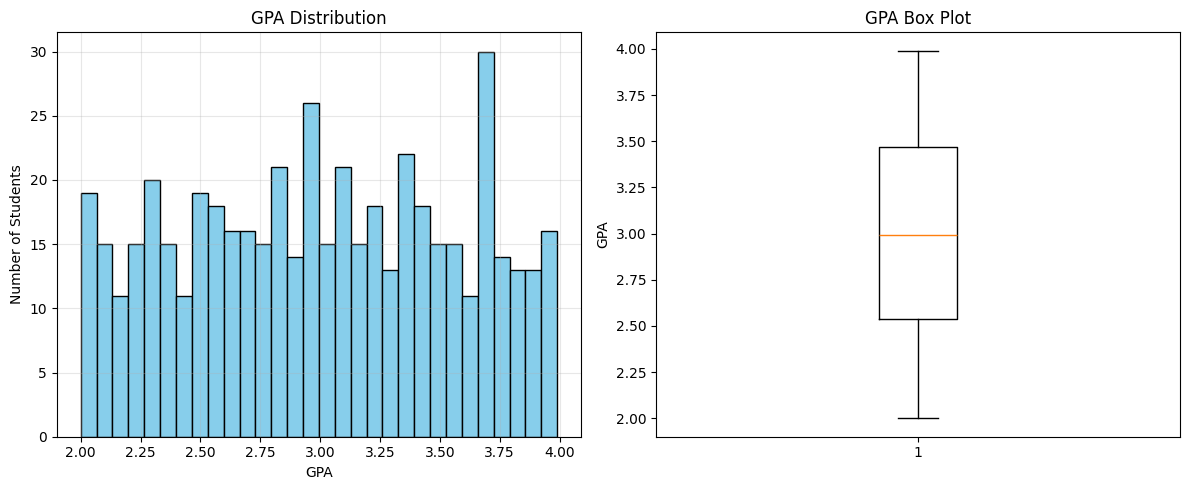

In [183]:
# Plot GPA distribution
plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(students['gpa'], bins=30, color='skyblue', edgecolor='black')
plt.title('GPA Distribution')
plt.xlabel('GPA')
plt.ylabel('Number of Students')
plt.grid(True, alpha=0.3)

# Box plot
plt.subplot(1, 2, 2)
plt.boxplot(students['gpa'])
plt.title('GPA Box Plot')
plt.ylabel('GPA')

plt.tight_layout()
plt.show()

**Course Distribution**

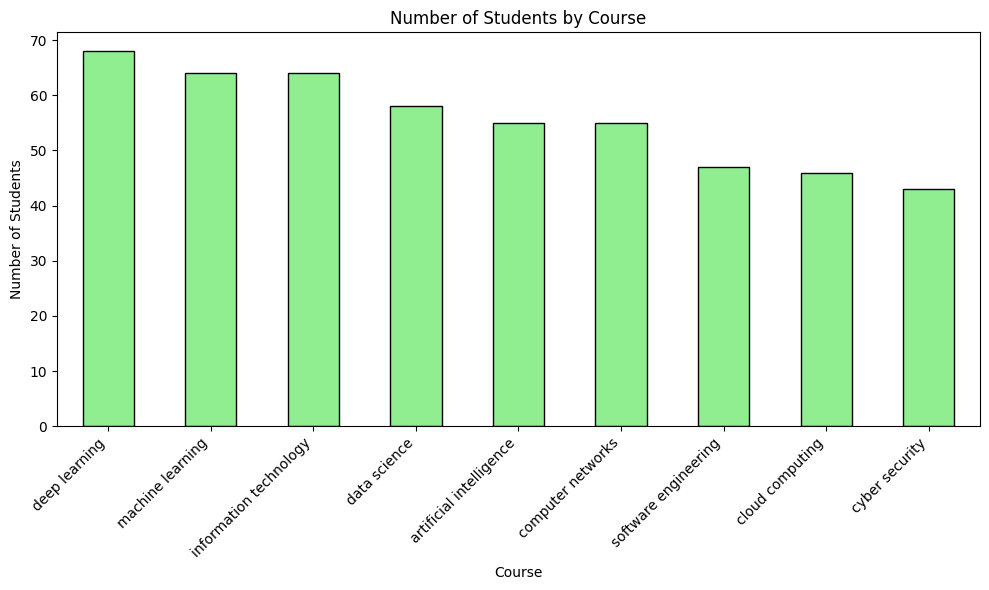

<========== COURSE DISTRIBUTION ==========>
deep learning: 68 students (13.6%)
machine learning: 64 students (12.8%)
information technology: 64 students (12.8%)
data science: 58 students (11.6%)
artificial intelligence: 55 students (11.0%)
computer networks: 55 students (11.0%)
software engineering: 47 students (9.4%)
cloud computing: 46 students (9.2%)
cyber security: 43 students (8.6%)




In [202]:
# Course distribution
course_counts = students['course'].value_counts()

plt.figure(figsize=(10, 6))
course_counts.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Number of Students by Course')
plt.xlabel('Course')
plt.ylabel('Number of Students')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Show course statistics
print("<========== COURSE DISTRIBUTION ==========>")
for course, count in course_counts.items():
    percentage = (count / len(students)) * 100
    print(f"{course}: {count} students ({percentage:.1f}%)")
print("\n")

**Learning style Distribution**

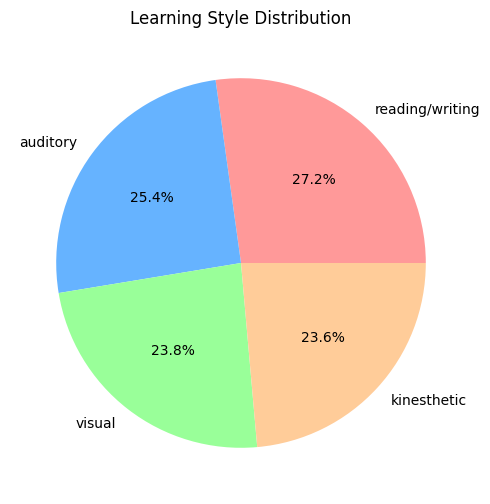

<========== LEARNING STYLE DISTRIBUTION ==========>
reading/writing: 136 students
auditory: 127 students
visual: 119 students
kinesthetic: 118 students




In [203]:
# Learning style distribution
learning_counts = students['learning_style'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(learning_counts.values, labels=learning_counts.index, autopct='%1.1f%%', 
        colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
plt.title('Learning Style Distribution')
plt.show()

print("<========== LEARNING STYLE DISTRIBUTION ==========>")
for style, count in learning_counts.items():
    print(f"{style}: {count} students")
print("\n")

**Communication skills Distribution**

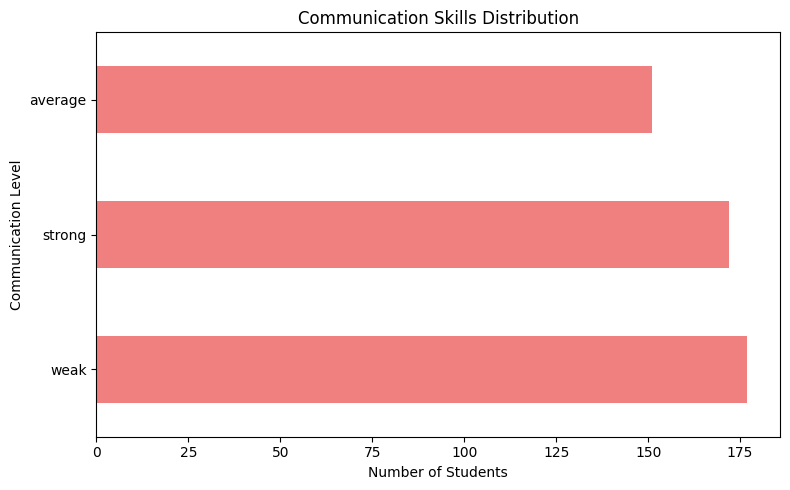

<========== COMMUNICATION SKILLS ==========>
weak: 177 students
strong: 172 students
average: 151 students




In [204]:
# Communication skills distribution
comm_counts = students['communication'].value_counts()

plt.figure(figsize=(8, 5))
comm_counts.plot(kind='barh', color='lightcoral')
plt.title('Communication Skills Distribution')
plt.xlabel('Number of Students')
plt.ylabel('Communication Level')
plt.tight_layout()
plt.show()

print("<========== COMMUNICATION SKILLS ==========>")
for level, count in comm_counts.items():
    print(f"{level}: {count} students")
print("\n")

**Personality Distribution**

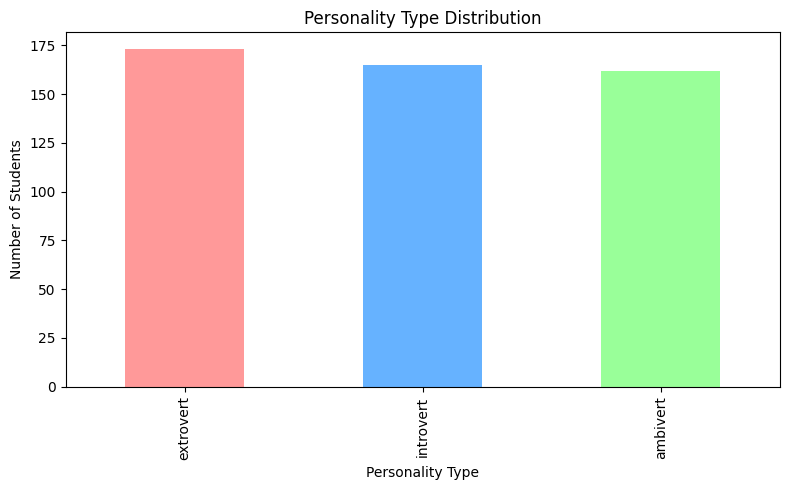

<========== PERSONALITY TYPES ==========>
extrovert: 173 students
introvert: 165 students
ambivert: 162 students




In [205]:
# Personality distribution
personality_counts = students['personality'].value_counts()

plt.figure(figsize=(8, 5))
personality_counts.plot(kind='bar', color=['#FF9999', '#66B2FF', '#99FF99'])
plt.title('Personality Type Distribution')
plt.xlabel('Personality Type')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.show()

print("<========== PERSONALITY TYPES ==========>")
for personality, count in personality_counts.items():
    print(f"{personality}: {count} students")
print("\n")

# **Bivariate Analysis**

**Average GPA by course**

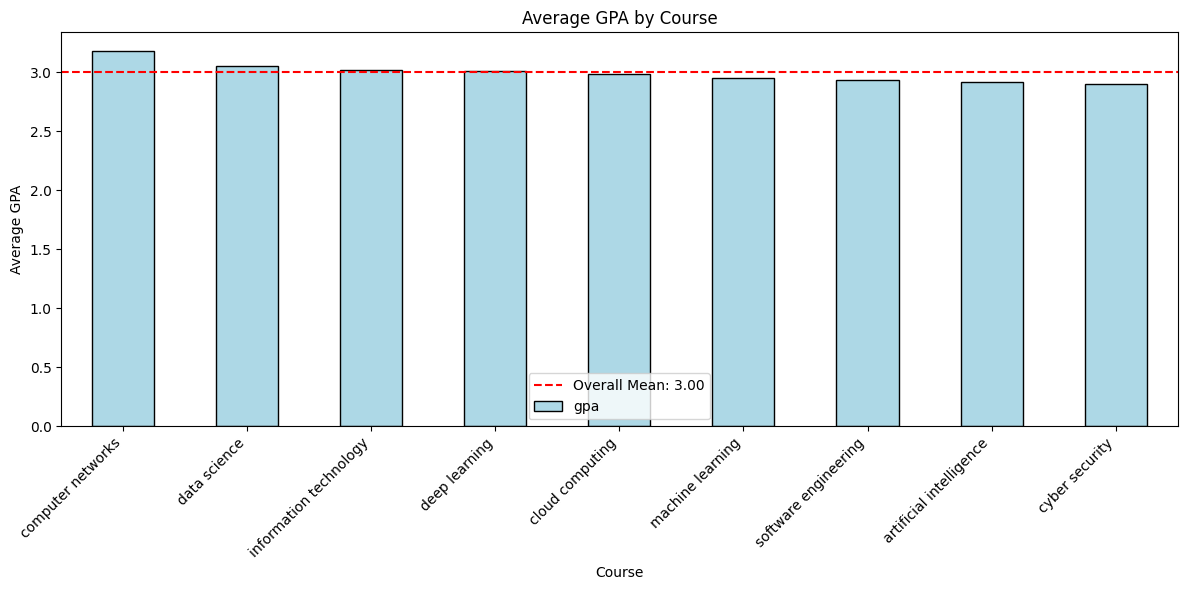

<========== AVERAGE GPA BY COURSE ==========>
computer networks: 3.18
data science: 3.06
information technology: 3.02
deep learning: 3.01
cloud computing: 2.99
machine learning: 2.96
software engineering: 2.94
artificial intelligence: 2.92
cyber security: 2.90




In [206]:
# Average GPA by course
gpa_by_course = students.groupby('course')['gpa'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
gpa_by_course.plot(kind='bar', color='lightblue', edgecolor='black')
plt.title('Average GPA by Course')
plt.xlabel('Course')
plt.ylabel('Average GPA')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=students['gpa'].mean(), color='red', linestyle='--', label=f'Overall Mean: {students["gpa"].mean():.2f}')
plt.legend()
plt.tight_layout()
plt.show()

print("<========== AVERAGE GPA BY COURSE ==========>")
for course, avg_gpa in gpa_by_course.items():
    print(f"{course}: {avg_gpa:.2f}")
print("\n")

**Average GPA by learning style**

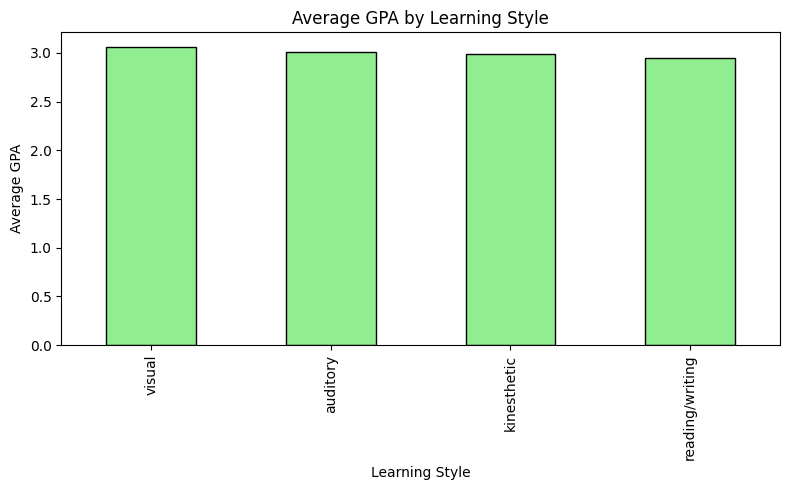

<========== AVERAGE GPA BY LEARNING STYLE ==========>
visual: 3.06
auditory: 3.01
kinesthetic: 2.99
reading/writing: 2.95




In [207]:
# Average GPA by learning style
gpa_by_learning = students.groupby('learning_style')['gpa'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
gpa_by_learning.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Average GPA by Learning Style')
plt.xlabel('Learning Style')
plt.ylabel('Average GPA')
plt.tight_layout()
plt.show()

print("<========== AVERAGE GPA BY LEARNING STYLE ==========>")
for style, avg_gpa in gpa_by_learning.items():
    print(f"{style}: {avg_gpa:.2f}")
print("\n")

**Average GPA by communication skills**

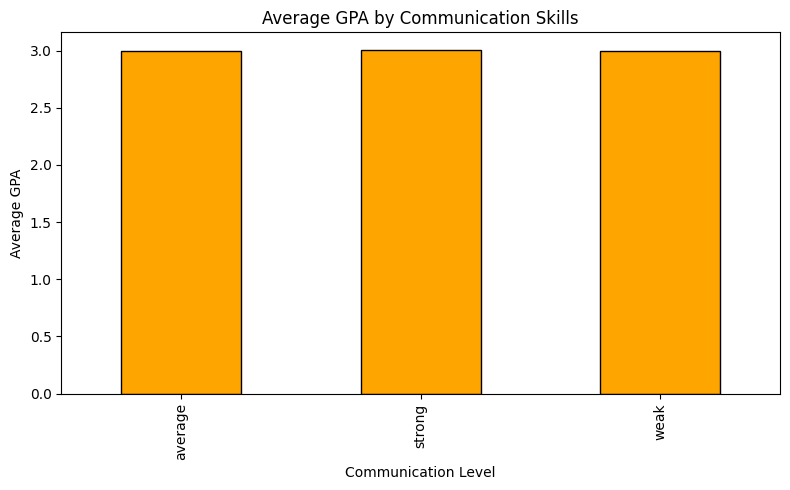

<========== AVERAGE GPA BY COMMUNICATION ==========>
average: 3.00
strong: 3.01
weak: 3.00




In [208]:
# Average GPA by communication skills
gpa_by_comm = students.groupby('communication')['gpa'].mean()

plt.figure(figsize=(8, 5))
gpa_by_comm.plot(kind='bar', color='orange', edgecolor='black')
plt.title('Average GPA by Communication Skills')
plt.xlabel('Communication Level')
plt.ylabel('Average GPA')
plt.tight_layout()
plt.show()

print("<========== AVERAGE GPA BY COMMUNICATION ==========>")
for level, avg_gpa in gpa_by_comm.items():
    print(f"{level}: {avg_gpa:.2f}")
print("\n")

**Average GPA by personality**

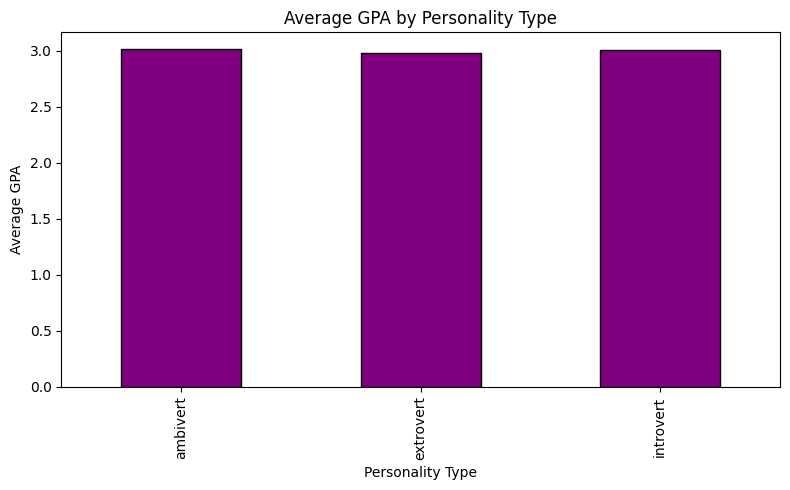

<========== AVERAGE GPA BY PERSONALITY ==========>
ambivert: 3.02
extrovert: 2.98
introvert: 3.01




In [209]:
# Average GPA by personality
gpa_by_personality = students.groupby('personality')['gpa'].mean()

plt.figure(figsize=(8, 5))
gpa_by_personality.plot(kind='bar', color='purple', edgecolor='black')
plt.title('Average GPA by Personality Type')
plt.xlabel('Personality Type')
plt.ylabel('Average GPA')
plt.tight_layout()
plt.show()

print("<========== AVERAGE GPA BY PERSONALITY ==========>")
for personality, avg_gpa in gpa_by_personality.items():
    print(f"{personality}: {avg_gpa:.2f}")
print("\n")

**Heatmap of Course vs Learning Style (% Distribution)**

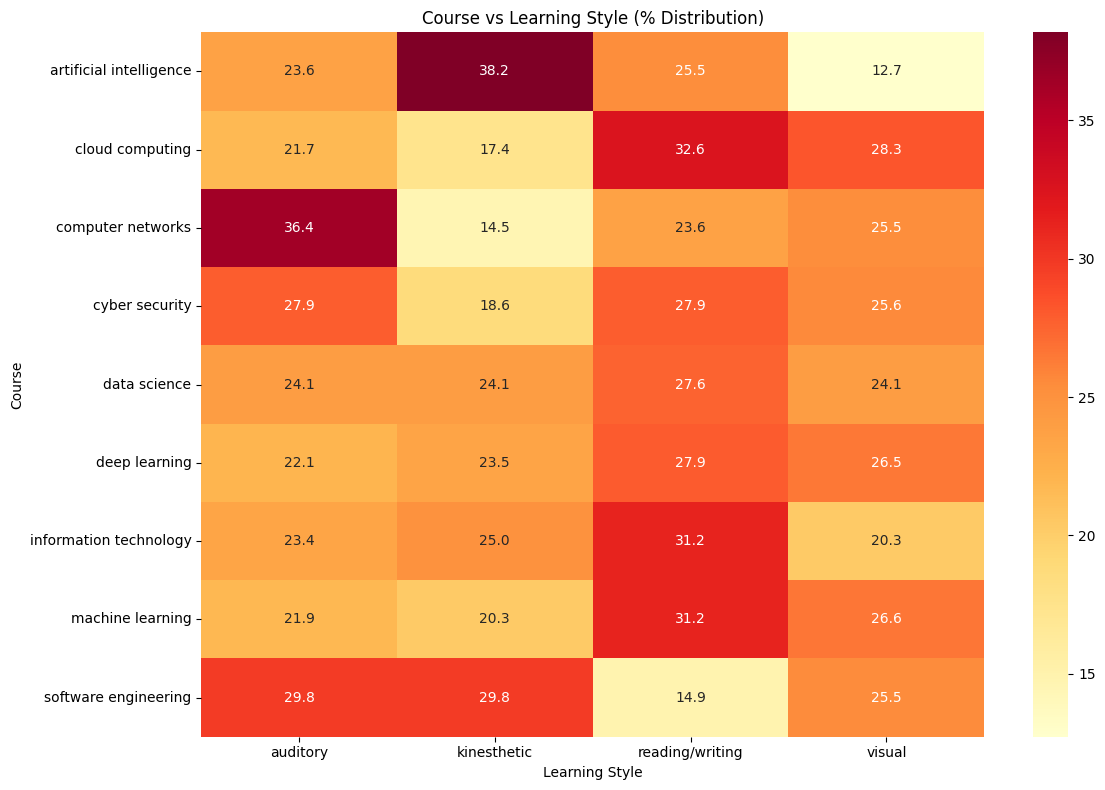

<========== COURSE VS LEARNING STYLE ==========>
Percentage distribution of learning styles in each course:
learning_style           auditory  kinesthetic  reading/writing  visual
course                                                                 
artificial intelligence      23.6         38.2             25.5    12.7
cloud computing              21.7         17.4             32.6    28.3
computer networks            36.4         14.5             23.6    25.5
cyber security               27.9         18.6             27.9    25.6
data science                 24.1         24.1             27.6    24.1
deep learning                22.1         23.5             27.9    26.5
information technology       23.4         25.0             31.2    20.3
machine learning             21.9         20.3             31.2    26.6
software engineering         29.8         29.8             14.9    25.5




In [210]:
# Create cross-tabulation
course_learning = pd.crosstab(students['course'], students['learning_style'], normalize='index') * 100

plt.figure(figsize=(12, 8))
sns.heatmap(course_learning, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Course vs Learning Style (% Distribution)')
plt.xlabel('Learning Style')
plt.ylabel('Course')
plt.tight_layout()
plt.show()

print("<========== COURSE VS LEARNING STYLE ==========>")
print("Percentage distribution of learning styles in each course:")
print(course_learning.round(1))
print("\n")

**Heatmap of Personality vs Communication Skills (% Distribution)**

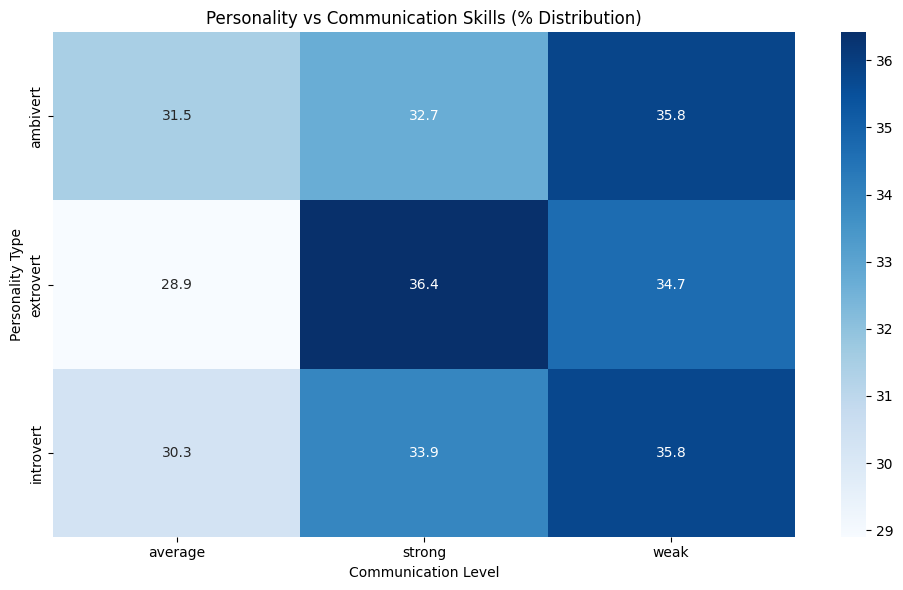

<========== PERSONALITY VS COMMUNICATION ==========>
Percentage distribution of communication levels for each personality:
communication  average  strong  weak
personality                         
ambivert          31.5    32.7  35.8
extrovert         28.9    36.4  34.7
introvert         30.3    33.9  35.8




In [211]:
# Create cross-tabulation
personality_comm = pd.crosstab(students['personality'], students['communication'], normalize='index') * 100

plt.figure(figsize=(10, 6))
sns.heatmap(personality_comm, annot=True, fmt='.1f', cmap='Blues')
plt.title('Personality vs Communication Skills (% Distribution)')
plt.xlabel('Communication Level')
plt.ylabel('Personality Type')
plt.tight_layout()
plt.show()

print("<========== PERSONALITY VS COMMUNICATION ==========>")
print("Percentage distribution of communication levels for each personality:")
print(personality_comm.round(1))
print("\n")

# **Multivariate Analysis**

**GPA by Course and Learning Style**

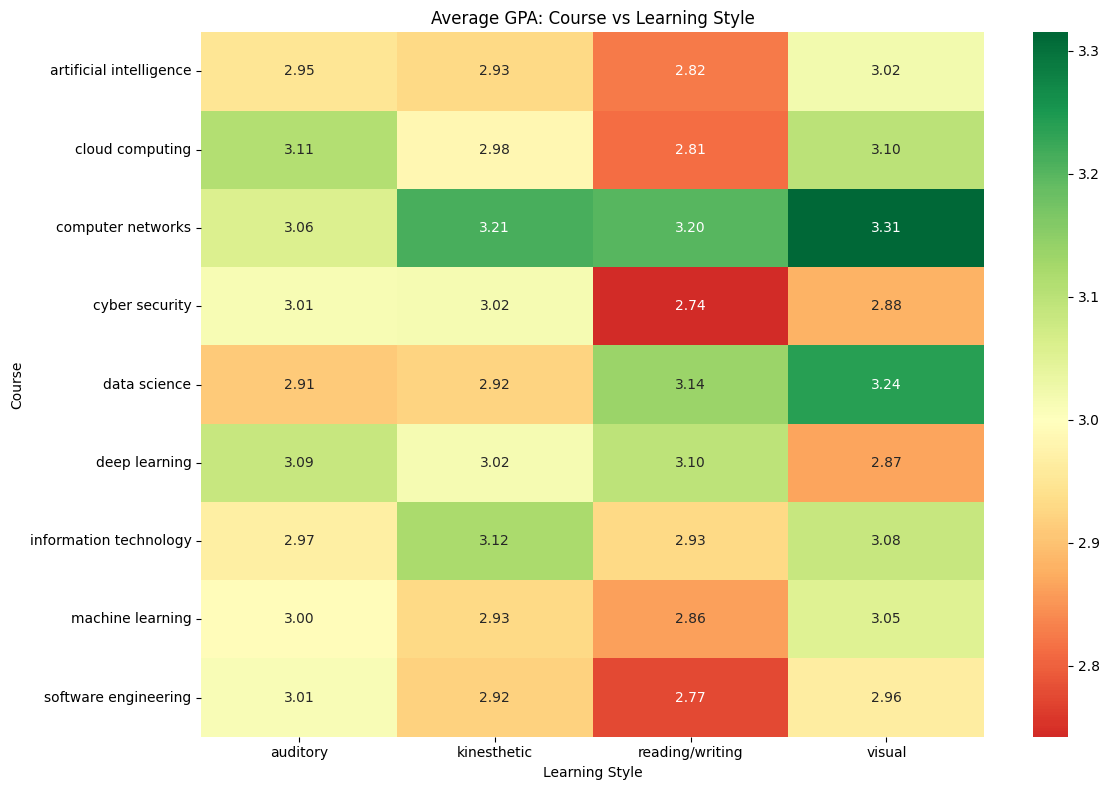

<========== GPA: COURSE VS LEARNING STYLE ==========>
Average GPA for each combination:
learning_style           auditory  kinesthetic  reading/writing  visual
course                                                                 
artificial intelligence      2.95         2.93             2.82    3.02
cloud computing              3.11         2.98             2.81    3.10
computer networks            3.06         3.21             3.20    3.32
cyber security               3.01         3.02             2.74    2.88
data science                 2.91         2.92             3.14    3.24
deep learning                3.09         3.02             3.10    2.87
information technology       2.97         3.12             2.93    3.08
machine learning             3.00         2.93             2.86    3.05
software engineering         3.01         2.92             2.77    2.96




In [212]:
# Create pivot table
gpa_pivot = students.pivot_table(values='gpa', index='course', columns='learning_style', aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(gpa_pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=3.0)
plt.title('Average GPA: Course vs Learning Style')
plt.xlabel('Learning Style')
plt.ylabel('Course')
plt.tight_layout()
plt.show()

print("<========== GPA: COURSE VS LEARNING STYLE ==========>")
print("Average GPA for each combination:")
print(gpa_pivot.round(2))
print("\n")

**GPA by Personality and Communication**

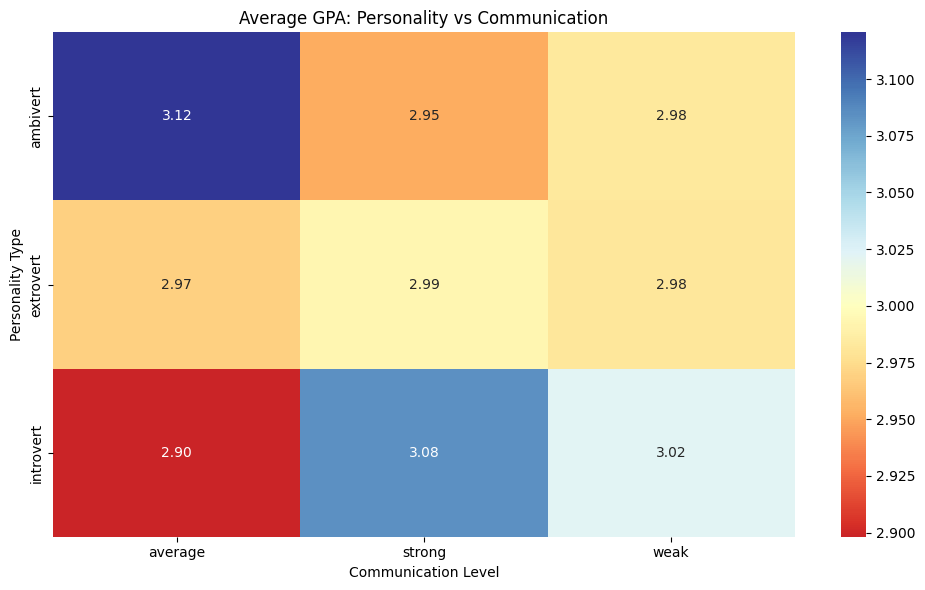

<========== GPA: PERSONALITY VS COMMUNICATION ==========>
Average GPA for each combination:
communication  average  strong  weak
personality                         
ambivert          3.12    2.95  2.98
extrovert         2.97    2.99  2.98
introvert         2.90    3.08  3.02




In [213]:
# Create pivot table
gpa_pivot2 = students.pivot_table(values='gpa', index='personality', columns='communication', aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(gpa_pivot2, annot=True, fmt='.2f', cmap='RdYlBu', center=3.0)
plt.title('Average GPA: Personality vs Communication')
plt.xlabel('Communication Level')
plt.ylabel('Personality Type')
plt.tight_layout()
plt.show()

print("<========== GPA: PERSONALITY VS COMMUNICATION ==========>")
print("Average GPA for each combination:")
print(gpa_pivot2.round(2))
print("\n")

**Top Performing Combinations**

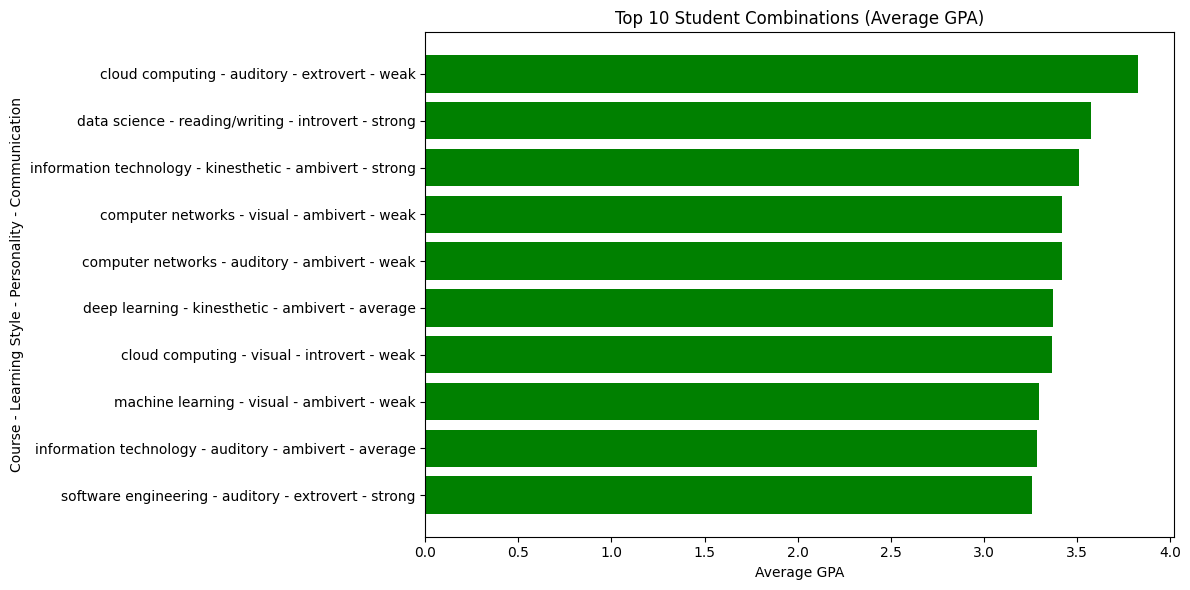

=== TOP 10 PERFORMING COMBINATIONS ===
(Minimum 3 students per combination)
1. cloud computing - auditory - extrovert - weak
   Average GPA: 3.83, Students: 3.0
2. data science - reading/writing - introvert - strong
   Average GPA: 3.58, Students: 3.0
3. information technology - kinesthetic - ambivert - strong
   Average GPA: 3.51, Students: 3.0
4. computer networks - visual - ambivert - weak
   Average GPA: 3.42, Students: 3.0
5. computer networks - auditory - ambivert - weak
   Average GPA: 3.42, Students: 3.0
6. deep learning - kinesthetic - ambivert - average
   Average GPA: 3.37, Students: 4.0
7. cloud computing - visual - introvert - weak
   Average GPA: 3.37, Students: 3.0
8. machine learning - visual - ambivert - weak
   Average GPA: 3.30, Students: 4.0
9. information technology - auditory - ambivert - average
   Average GPA: 3.29, Students: 3.0
10. software engineering - auditory - extrovert - strong
   Average GPA: 3.26, Students: 3.0




In [214]:
# Find top 10 student combinations
students['combination'] = students['course'] + " - " + students['learning_style'] + " - " + students['personality'] + " - " + students['communication']

top_combinations = students.groupby('combination')['gpa'].agg(['mean', 'count']).round(3)
top_combinations = top_combinations[top_combinations['count'] >= 3]  # Filter combinations with at least 3 students

top_10 = top_combinations.sort_values('mean', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_10.index, top_10['mean'], color='green')
plt.title('Top 10 Student Combinations (Average GPA)')
plt.xlabel('Average GPA')
plt.ylabel('Course - Learning Style - Personality - Communication')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("=== TOP 10 PERFORMING COMBINATIONS ===")
print("(Minimum 3 students per combination)")
for i, (combination, row) in enumerate(top_10.iterrows(), 1):
    print(f"{i}. {combination}")
    print(f"   Average GPA: {row['mean']:.2f}, Students: {row['count']}")
print("\n")

**Statistical Tests**

In [215]:
from scipy.stats import f_oneway, ttest_ind

print("<========== STATISTICAL TESTS ==========>")

# Test 1: GPA difference between courses
print("\n1. ANOVA Test: GPA differences between courses")
courses = students['course'].unique()
gpa_lists = []
for course in courses:
    gpa_lists.append(students[students['course'] == course]['gpa'])
    
f_stat, p_value = f_oneway(*gpa_lists)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    print("Result: Significant difference in GPA between courses (p < 0.05)")
else:
    print("Result: No significant difference in GPA between courses")
print("\n")

# Test 2: GPA difference between strong vs weak communicators
print("2. T-test: GPA difference (Strong vs Weak communicators)")
strong_gpa = students[students['communication'] == 'strong']['gpa']
weak_gpa = students[students['communication'] == 'weak']['gpa']

t_stat, p_value = ttest_ind(strong_gpa, weak_gpa)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    print("Result: Significant difference in GPA (p < 0.05)")
else:
    print("Result: No significant difference in GPA")
print("\n")

# Test 3: GPA difference between introverts and extroverts
print("3. T-test: GPA difference (Introverts vs Extroverts)")
introvert_gpa = students[students['personality'] == 'introvert']['gpa']
extrovert_gpa = students[students['personality'] == 'extrovert']['gpa']

t_stat, p_value = ttest_ind(introvert_gpa, extrovert_gpa)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    print("Result: Significant difference in GPA (p < 0.05)")
else:
    print("Result: No significant difference in GPA")
print("\n")

<========== STATISTICAL TESTS ==========>

1. ANOVA Test: GPA differences between courses
F-statistic: 1.2192
P-value: 0.2855
Result: No significant difference in GPA between courses


2. T-test: GPA difference (Strong vs Weak communicators)
T-statistic: 0.2342
P-value: 0.8150
Result: No significant difference in GPA


3. T-test: GPA difference (Introverts vs Extroverts)
T-statistic: 0.3770
P-value: 0.7064
Result: No significant difference in GPA




**Student Segmentation**

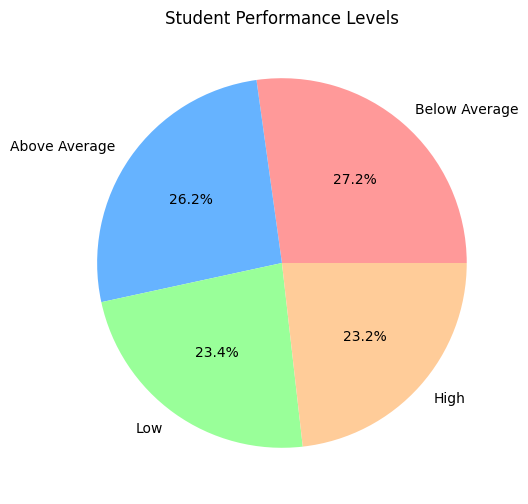

=== PERFORMANCE LEVEL DISTRIBUTION ===
Below Average GPA: 136 students (27.2%)
Above Average GPA: 131 students (26.2%)
Low GPA: 117 students (23.4%)
High GPA: 116 students (23.2%)


<========== CHARACTERISTICS OF HIGH PERFORMERS ==========>
Total high performers: 116

Top courses for high performers:
course
deep learning             20
computer networks         19
information technology    14
machine learning          13
data science              13
Name: count, dtype: int64

Learning styles of high performers:
learning_style
reading/writing    32
visual             31
auditory           28
kinesthetic        25
Name: count, dtype: int64

Communication skills of high performers:
communication
weak       47
strong     35
average    34
Name: count, dtype: int64

Personality types of high performers:
personality
extrovert    41
ambivert     38
introvert    37
Name: count, dtype: int64




In [216]:
# Create student segments based on performance
students['performance_level'] = pd.cut(students['gpa'], 
                                 bins=[0, 2.5, 3.0, 3.5, 4.0],
                                 labels=['Low', 'Below Average', 'Above Average', 'High'])

# Distribution of performance levels
performance_counts = students['performance_level'].value_counts()

plt.figure(figsize=(8, 6))
performance_counts.plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
plt.title('Student Performance Levels')
plt.ylabel('')
plt.show()

print("=== PERFORMANCE LEVEL DISTRIBUTION ===")
for level, count in performance_counts.items():
    percentage = (count / len(students)) * 100
    print(f"{level} GPA: {count} students ({percentage:.1f}%)")
print("\n")

# Analyze characteristics of high performers
high_performers = students[students['performance_level'] == 'High']

print("<========== CHARACTERISTICS OF HIGH PERFORMERS ==========>")
print(f"Total high performers: {len(high_performers)}")

print("\nTop courses for high performers:")
print(high_performers['course'].value_counts().head(5))

print("\nLearning styles of high performers:")
print(high_performers['learning_style'].value_counts())

print("\nCommunication skills of high performers:")
print(high_performers['communication'].value_counts())

print("\nPersonality types of high performers:")
print(high_performers['personality'].value_counts())
print("\n")

**Correlation Analysis**

<========== CORRELATION ANALYSIS ==========>


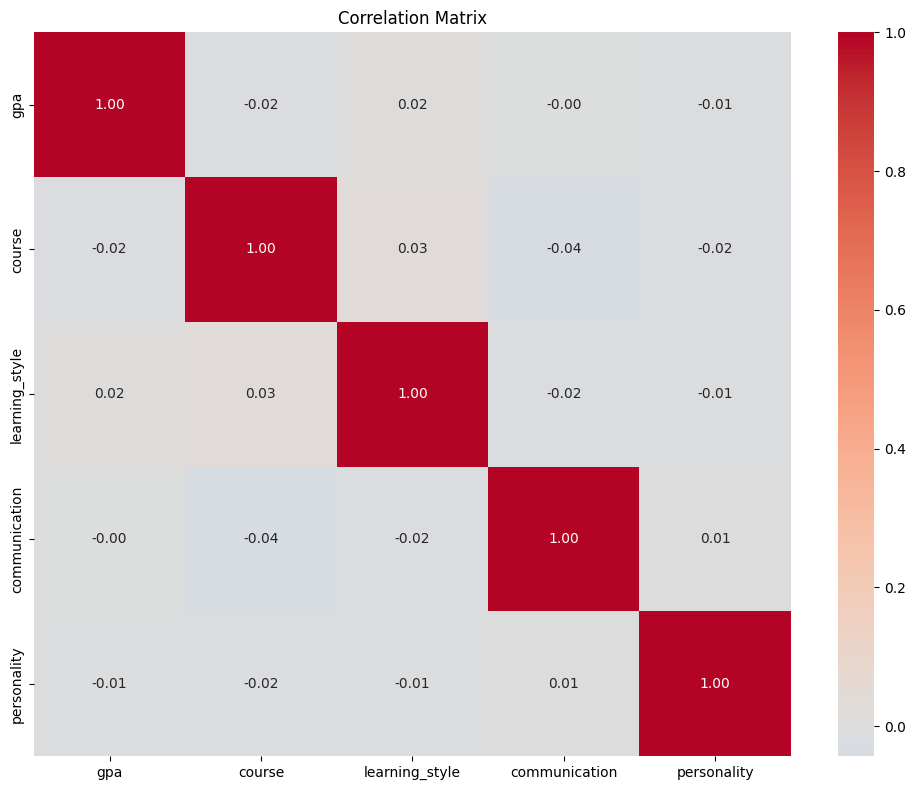

=== CORRELATION WITH GPA ===
learning_style: 0.016
communication: -0.001
personality: -0.007
course: -0.019




In [217]:
# Fix for Correlation Analysis - Section 8
print("<========== CORRELATION ANALYSIS ==========>")

# Convert categorical variables to numeric for correlation
from sklearn.preprocessing import LabelEncoder

# Create encoded dataframe - EXCLUDE performance_level
encoded_df = students[['gpa', 'course', 'learning_style', 'communication', 'personality']].copy()

# Encode categorical variables
label_encoders = {}
for col in ['course', 'learning_style', 'communication', 'personality']:
    le = LabelEncoder()
    encoded_df[col] = le.fit_transform(students[col])
    label_encoders[col] = le

# Now calculate correlations (no string columns)
correlation_matrix = encoded_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

print("=== CORRELATION WITH GPA ===")
gpa_correlations = correlation_matrix['gpa'].sort_values(ascending=False)
for variable, correlation in gpa_correlations.items():
    if variable != 'gpa':
        # Convert back to original variable names
        if variable == 'course_encoded':
            var_name = 'course'
        elif variable == 'learning_style_encoded':
            var_name = 'learning_style'
        elif variable == 'communication_encoded':
            var_name = 'communication'
        elif variable == 'personality_encoded':
            var_name = 'personality'
        else:
            var_name = variable
        print(f"{var_name}: {correlation:.3f}")
print("\n")

**Summary and Insights**

In [200]:
print("="*80)
print("SUMMARY REPORT AND KEY INSIGHTS")
print("="*80)

# Basic statistics
print("\n1. OVERALL STATISTICS:")
print(f"   • Total students analyzed: {len(students)}")
print(f"   • Average GPA: {students['gpa'].mean():.2f}")
print(f"   • GPA range: {students['gpa'].min():.2f} to {students['gpa'].max():.2f}")
print(f"   • Most common course: {students['course'].value_counts().index[0]}")

# Top findings
print("\n2. TOP FINDINGS:")
print(f"   • Course with highest average GPA: {gpa_by_course.index[0]} ({gpa_by_course.iloc[0]:.2f})")
print(f"   • Learning style with highest average GPA: {gpa_by_learning.index[0]} ({gpa_by_learning.iloc[0]:.2f})")
print(f"   • Communication level with highest average GPA: {gpa_by_comm.index[0]} ({gpa_by_comm.iloc[0]:.2f})")
print(f"   • Personality type with highest average GPA: {gpa_by_personality.index[0]} ({gpa_by_personality.iloc[0]:.2f})")

# Statistical insights
print("\n3. STATISTICAL INSIGHTS:")
print(f"   • Significant GPA differences between courses: {'Yes' if f_oneway(*gpa_lists)[1] < 0.05 else 'No'}")
print(f"   • Strong communicators vs weak communicators GPA difference: {gpa_by_comm['strong'] - gpa_by_comm['weak']:.2f}")
print(f"   • Introverts vs extroverts GPA difference: {gpa_by_personality['introvert'] - gpa_by_personality['extrovert']:.2f}")

# Recommendations
print("\n4. RECOMMENDATIONS:")
print("   • Focus on supporting students in courses with lower average GPA")
print("   • Consider learning styles when designing course materials")
print("   • Provide communication skill development opportunities")
print("   • Use personality types to form balanced study groups")

print("\n5. FUTURE WORK:")
print("   • Collect more student background information")
print("   • Track GPA changes over time")
print("   • Add course difficulty ratings")
print("   • Include student satisfaction surveys")

print("\n" + "="*80)

SUMMARY REPORT AND KEY INSIGHTS

1. OVERALL STATISTICS:
   • Total students analyzed: 500
   • Average GPA: 3.00
   • GPA range: 2.00 to 3.99
   • Most common course: deep learning

2. TOP FINDINGS:
   • Course with highest average GPA: computer networks (3.18)
   • Learning style with highest average GPA: visual (3.06)
   • Communication level with highest average GPA: average (3.00)
   • Personality type with highest average GPA: ambivert (3.02)

3. STATISTICAL INSIGHTS:
   • Significant GPA differences between courses: No
   • Strong communicators vs weak communicators GPA difference: 0.01
   • Introverts vs extroverts GPA difference: 0.02

4. RECOMMENDATIONS:
   • Focus on supporting students in courses with lower average GPA
   • Consider learning styles when designing course materials
   • Provide communication skill development opportunities
   • Use personality types to form balanced study groups

5. FUTURE WORK:
   • Collect more student background information
   • Track GPA c

**Export Results**

In [201]:
# Export processed data
students.to_csv('processed_student_data.csv', index=False)
print("Processed data saved as 'processed_student_data.csv'")

# Export summary statistics
summary_stats = pd.DataFrame({
    'Statistic': ['Total Students', 'Average GPA', 'Min GPA', 'Max GPA', 'GPA Std Dev'],
    'Value': [len(students), students['gpa'].mean(), students['gpa'].min(), students['gpa'].max(), students['gpa'].std()]
})
summary_stats.to_csv('summary_statistics.csv', index=False)
print("Summary statistics saved as 'summary_statistics.csv'")

# Export GPA by course
gpa_by_course_df = pd.DataFrame(gpa_by_course).reset_index()
gpa_by_course_df.columns = ['Course', 'Average GPA']
gpa_by_course_df.to_csv('gpa_by_course.csv', index=False)
print("GPA by course saved as 'gpa_by_course.csv'")

print("\nAll files exported successfully!")

Processed data saved as 'processed_student_data.csv'
Summary statistics saved as 'summary_statistics.csv'
GPA by course saved as 'gpa_by_course.csv'

All files exported successfully!
